In [216]:
import yfinance as yf
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

ticker = yf.Ticker("AAPL")
df = ticker.history(period="5y", interval="1d")

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [217]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2021-06-23 00:00:00-04:00,130.392581,130.928697,129.866206,130.324341,60214200
2021-06-24 00:00:00-04:00,131.055377,131.240582,129.573750,130.041641,68711000
2021-06-25 00:00:00-04:00,130.090452,130.509588,129.456854,129.749283,70783700
2021-06-28 00:00:00-04:00,130.041655,131.835195,129.983172,131.377060,62111300
2021-06-29 00:00:00-04:00,131.396570,133.043903,130.957935,132.887939,64556100
...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200


In [218]:
# ---------------------------------------------------------
# 1. VWAP (Volume Weighted Average Price)
# The Institutional Benchmark. Must reset monthly.
# ---------------------------------------------------------

# 2. Calculate the Typical Price and Price-Volume (PV)
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
df['PV'] = df['Typical_Price'] * df['Volume']

# 3. Create Year and Month columns to act as our "Anchor"
df['Year'] = df.index.year
df['Month'] = df.index.month

# 4. The Monthly Anchor: Group by Year AND Month to reset the sum on the 1st
df['Cumulative_PV'] = df.groupby(['Year', 'Month'])['PV'].cumsum()
df['Cumulative_Vol'] = df.groupby(['Year', 'Month'])['Volume'].cumsum()

# 5. Calculate the final Monthly VWAP
df['Monthly_VWAP'] = df['Cumulative_PV'] / df['Cumulative_Vol']

# Clean up temporary columns
df = df.drop(columns=['Typical_Price', 'PV', 'Cumulative_PV', 'Cumulative_Vol', 'Year', 'Month'])

# ---------------------------------------------------------
# 2. RSI (Relative Strength Index)
# The Momentum Spring Coil. (Standard 14-period)
# ---------------------------------------------------------
# Find the difference in closing price from the previous 5-day
delta = df['Close'].diff()

# Separate the positive gains from the negative losses
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)

# Calculate the Exponential Moving Average (EMA) of gains and losses
avg_gain = gain.ewm(com=14 - 1, adjust=False).mean()
avg_loss = loss.ewm(com=14 - 1, adjust=False).mean()

# Calculate the Relative Strength (RS)
rs = avg_gain / avg_loss

# Convert into an oscillator that bounces between 0 and 100
df['RSI'] = 100 - (100 / (1 + rs))

# ---------------------------------------------------------
# 3. ATR (Average True Range)
# The Volatility Risk Manager. (Standard 14-period)
# ---------------------------------------------------------
df['Prev_Close'] = df['Close'].shift(1)

# True Range is the MAXIMUM of these three volatility measures
df['TR1'] = df['High'] - df['Low'] # Current candle range
df['TR2'] = (df['High'] - df['Prev_Close']).abs() # Gap up from last close
df['TR3'] = (df['Low'] - df['Prev_Close']).abs()  # Gap down from last close

# Find the max value across the columns for each row
df['True_Range'] = df[['TR1', 'TR2', 'TR3']].max(axis=1)

# Smooth it out with a 14-period rolling mean
df['ATR'] = df['True_Range'].rolling(window=14).mean()

# ---------------------------------------------------------
# 4. Clean Up
# ---------------------------------------------------------
# Drop the intermediate columns we used for math so the dataframe is clean
columns_to_drop = ['Prev_Close', 'TR1', 'TR2', 'TR3', 'True_Range']
df = df.drop(columns=columns_to_drop)

# Drop early rows that have NaNs due to rolling windows
df = df.dropna()

df

,Open,High,Low,Close,Volume,Monthly_VWAP,RSI,ATR
Date,,,,,,,,
2021-07-13 00:00:00-04:00,140.393524,143.736931,140.003629,141.962875,100827100,139.213986,74.290686,2.305287
2021-07-14 00:00:00-04:00,144.360754,145.793640,143.951345,145.384232,127050800,140.081111,79.963269,2.503021
2021-07-15 00:00:00-04:00,145.471976,146.212782,143.376251,144.731155,106820300,140.602740,76.493770,2.586571
2021-07-16 00:00:00-04:00,144.711667,145.978833,142.196806,142.693924,93251400,140.869933,66.762492,2.781521
2021-07-19 00:00:00-04:00,140.120605,140.432532,138.093119,138.853424,121434600,140.689826,53.058908,2.961156
...,...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,302.286588,52.160660,7.880718
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,301.976305,48.923303,8.200721
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,301.528723,50.975047,8.163579


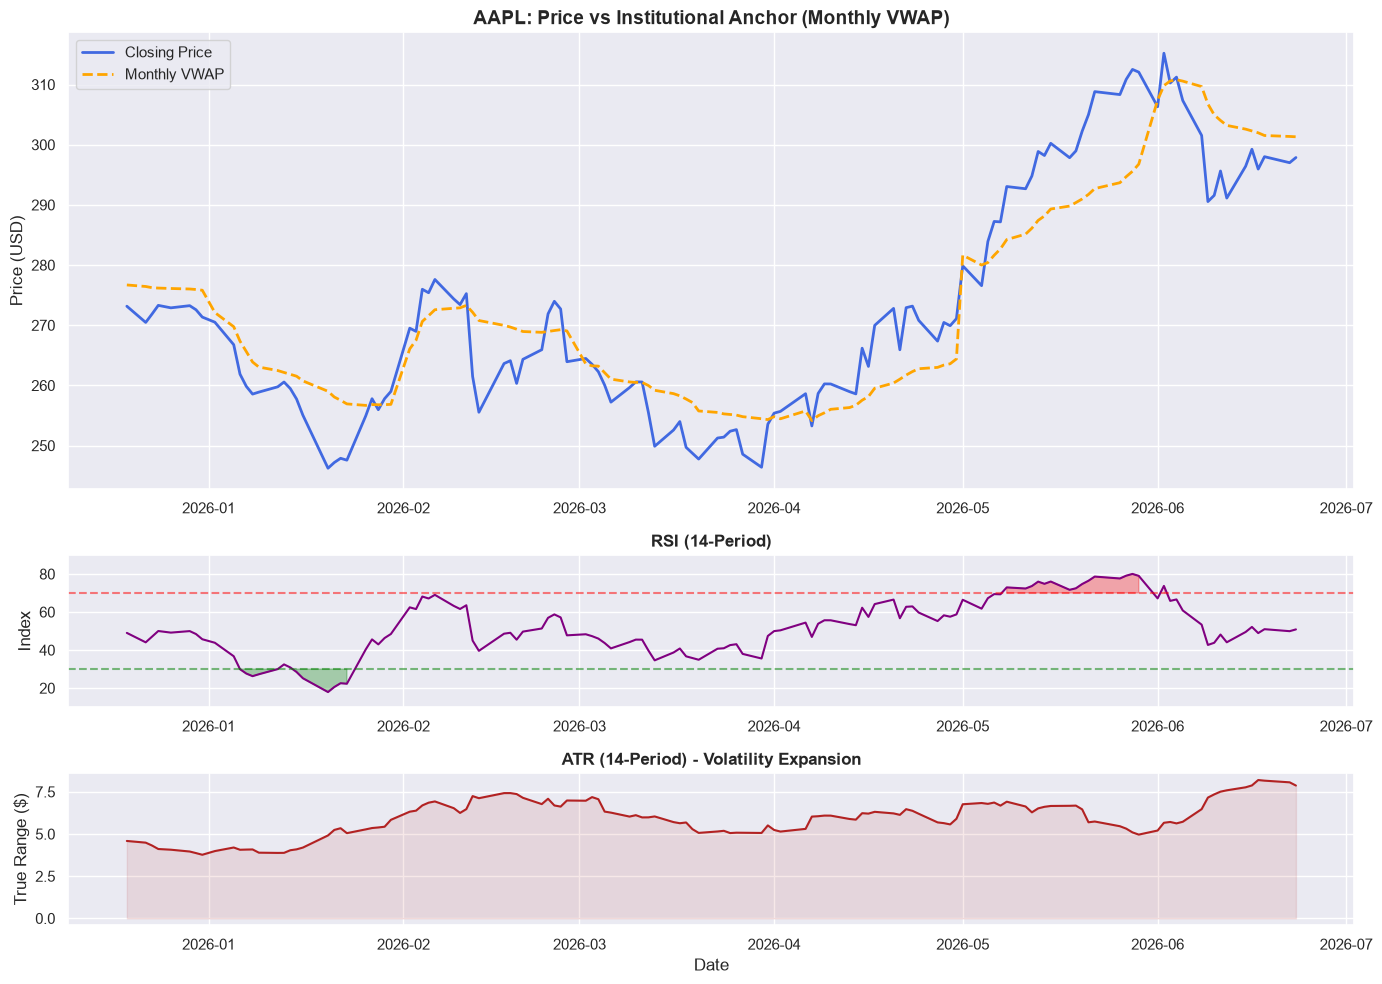

In [219]:
plot_df = df.tail(126)

# Set a clean, professional financial theme
sns.set_theme(style="darkgrid")

# Create a figure with 3 vertically stacked subplots
# height_ratios makes the Price chart larger than the indicators below it
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1, 1]})

# ---------------------------------------------------------
# Top Chart: Price and Monthly VWAP
# ---------------------------------------------------------
ax1.plot(plot_df.index, plot_df['Close'], label='Closing Price', color='royalblue', linewidth=2)
ax1.plot(plot_df.index, plot_df['Monthly_VWAP'], label='Monthly VWAP', color='orange', linestyle='--', linewidth=2)

ax1.set_title("AAPL: Price vs Institutional Anchor (Monthly VWAP)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price (USD)")
ax1.legend(loc='upper left')

# ---------------------------------------------------------
# Middle Chart: RSI (The Momentum Spring)
# ---------------------------------------------------------
ax2.plot(plot_df.index, plot_df['RSI'], color='purple', linewidth=1.5)

# Draw the Overbought (70) and Oversold (30) boundary lines
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)

# Fill the extreme zones so they visually pop out to you
ax2.fill_between(plot_df.index, plot_df['RSI'], 70, where=(plot_df['RSI'] >= 70), color='red', alpha=0.3)
ax2.fill_between(plot_df.index, plot_df['RSI'], 30, where=(plot_df['RSI'] <= 30), color='green', alpha=0.3)

ax2.set_title("RSI (14-Period)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Index")
ax2.set_ylim(10, 90)

# ---------------------------------------------------------
# Bottom Chart: ATR (The Volatility Engine)
# ---------------------------------------------------------
ax3.plot(plot_df.index, plot_df['ATR'], color='firebrick', linewidth=1.5)

# Fill under the ATR line to show volatility "swells"
ax3.fill_between(plot_df.index, plot_df['ATR'], 0, color='firebrick', alpha=0.1)

ax3.set_title("ATR (14-Period) - Volatility Expansion", fontsize=12, fontweight='bold')
ax3.set_ylabel("True Range ($)")
ax3.set_xlabel("Date")

# Clean up layout so labels don't overlap
plt.tight_layout()
plt.show()

In [220]:
# ---------------------------------------------------------
# Fetch Data & Calculate Indicators
# ---------------------------------------------------------

# Calculate the 21-Day Simple Moving Average (The Trend)
df['SMA_21'] = df['Close'].rolling(window=21).mean()
df['SMA_42'] = df['Close'].rolling(window=42).mean()
df['SMA_63'] = df['Close'].rolling(window=63).mean()


# Calculate the Standard Deviation (The Volatility)
df['Std_Dev'] = df['Close'].rolling(window=21).std()

# Calculate Bollinger Bands (2 Standard Deviations up and down)
df['Upper_Band'] = df['SMA_21'] + (df['Std_Dev'] * 2)
df['Lower_Band'] = df['SMA_21'] - (df['Std_Dev'] * 2)

df = df.dropna()
df

,Open,High,Low,Close,Volume,Monthly_VWAP,RSI,ATR,SMA_21,SMA_42,SMA_63,Std_Dev,Upper_Band,Lower_Band
Date,,,,,,,,,,,,,,
2021-10-08 00:00:00-04:00,140.603842,140.750268,139.168809,139.500717,58773200,138.054670,44.433943,2.754318,141.280704,144.124036,143.685180,2.999042,147.278788,135.282620
2021-10-11 00:00:00-04:00,138.885739,141.365312,138.436675,139.412888,64452200,138.254878,44.230780,2.836598,140.994348,144.053144,143.644704,2.867624,146.729595,135.259100
2021-10-12 00:00:00-04:00,139.822885,139.842414,137.684978,138.143799,73035900,138.290763,41.292849,2.781507,140.620597,143.881610,143.529776,2.689566,145.999728,135.241466
2021-10-13 00:00:00-04:00,137.880257,138.036440,135.888776,137.558105,78762700,138.162520,39.973228,2.842170,140.285432,143.691248,143.415918,2.606594,145.498620,135.072243
2021-10-14 00:00:00-04:00,138.729527,140.457427,138.143793,140.340271,69907100,138.298419,48.407678,2.916081,140.040448,143.520178,143.378559,2.319425,144.679297,135.401599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,302.286588,52.160660,7.880718,303.478572,292.146306,279.708006,7.675541,318.829654,288.127491
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,301.976305,48.923303,8.200721,303.388573,292.764610,280.441976,7.755624,318.899821,287.877325
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,301.528723,50.975047,8.163579,303.342859,293.364881,281.224185,7.785741,318.914342,287.771377


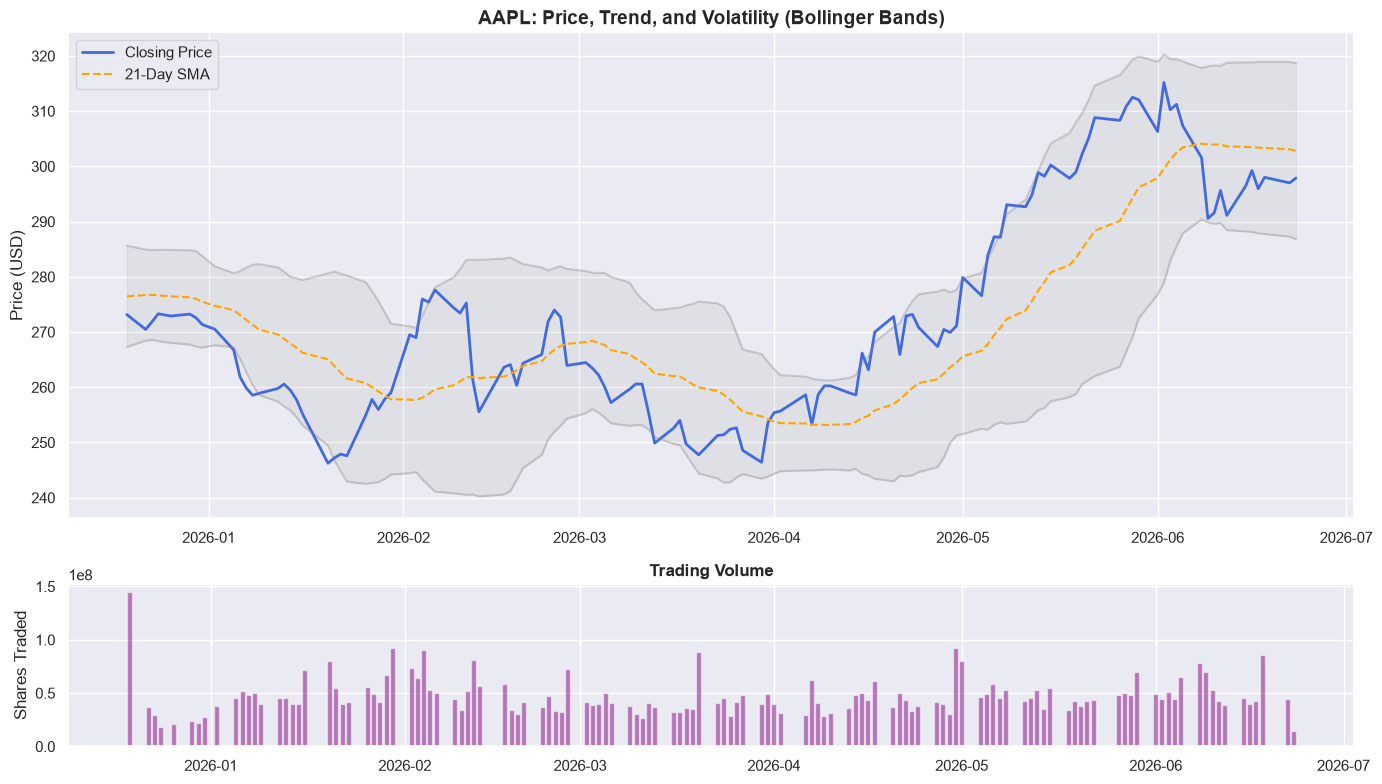

In [221]:
plot_df = df.tail(126)

# ---------------------------------------------------------
# 1. Visualization Setup
# ---------------------------------------------------------
# Apply Seaborn's dark theme for a clean, analytical look
sns.set_theme(style="darkgrid")

# Create a figure with 2 subplots (Price on top, Volume on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# ---------------------------------------------------------
# 2. Top Chart: Price and Bollinger Bands
# ---------------------------------------------------------
sns.lineplot(data=plot_df, x=plot_df.index, y='Close', label='Closing Price', color='royalblue', linewidth=2, ax=ax1)
sns.lineplot(data=plot_df, x=plot_df.index, y='SMA_21', label='21-Day SMA', color='orange', linestyle='--', ax=ax1)

# Plot the invisible boundary lines for the bands
sns.lineplot(data=plot_df, x=plot_df.index, y='Upper_Band', color='gray', alpha=0.3, ax=ax1)
sns.lineplot(data=plot_df, x=plot_df.index, y='Lower_Band', color='gray', alpha=0.3, ax=ax1)

# Fill the "volatility envelope" between the upper and lower bands
ax1.fill_between(plot_df.index, plot_df['Lower_Band'], plot_df['Upper_Band'], color='gray', alpha=0.1)

ax1.set_title("AAPL: Price, Trend, and Volatility (Bollinger Bands)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price (USD)")
ax1.set_xlabel("") # Hide x-label to keep it clean

# ---------------------------------------------------------
# 3. Bottom Chart: Volume
# ---------------------------------------------------------
# Matplotlib handles datetime bar charts a bit cleaner than Seaborn here
ax2.bar(plot_df.index, plot_df['Volume'], color='purple', alpha=0.5)
ax2.set_title("Trading Volume", fontsize=12, fontweight='bold')
ax2.set_ylabel("Shares Traded")

# Clean up layout and display
plt.tight_layout()
plt.show()

In [222]:
# Calculate the daily percentage return
df['Daily_Return'] = df['Close'].pct_change()

# ---------------------------------------------------------
# 1. The Bins (Grounded in S&P 500 Reality)
# ---------------------------------------------------------
# Boundaries: Crash (< -2%), Chop (-2% to +2%), Rally (2% to 5%), Moon (> 5%)
bins = [-np.inf, -0.02, 0.02, 0.05, np.inf]
labels = [-1, 0, 1, 2]

# ---------------------------------------------------------
# 2. Your Genius Feature: The Lagged State
# ---------------------------------------------------------
# We categorize TODAY's return, and then immediately .shift(1) 
# so it represents YESTERDAY's state on today's row.
df['Yesterday_State'] = pd.cut(df['Daily_Return'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 3. The Target Variable: Tomorrow's State
# ---------------------------------------------------------
# We shift the raw return UP by 1 to get tomorrow's return, then bin it.
df['Tomorrow_Return'] = df['Daily_Return'].shift(-1)
df['Target'] = pd.cut(df['Tomorrow_Return'], bins=bins, labels=labels)

# Clean up the raw return columns to prevent data leakage, and drop NaNs
# df = df.drop(columns=['Daily_Return', 'Tomorrow_Return']).dropna()

df[['Close', 'Daily_Return', 'Tomorrow_Return', 'Yesterday_State', 'Target']]

C:\Users\rites\AppData\Local\Temp\ipykernel_12568\1538143798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Daily_Return'] = df['Close'].pct_change()
C:\Users\rites\AppData\Local\Temp\ipykernel_12568\1538143798.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Yesterday_State'] = pd.cut(df['Daily_Return'], bins=bins, labels=labels)
C:\Users\rites\AppData\Local\Temp\ipykernel_12568\1538143798.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

,Close,Daily_Return,Tomorrow_Return,Yesterday_State,Target
Date,,,,,
2021-10-08 00:00:00-04:00,139.500717,NaN,-0.000630,NaN,0
2021-10-11 00:00:00-04:00,139.412888,-0.000630,-0.009103,0,0
2021-10-12 00:00:00-04:00,138.143799,-0.009103,-0.004240,0,0
2021-10-13 00:00:00-04:00,137.558105,-0.004240,0.020225,0,1
2021-10-14 00:00:00-04:00,140.340271,0.020225,0.007513,1,0
...,...,...,...,...,...
2026-06-16 00:00:00-04:00,299.239990,0.009513,-0.010994,0,0
2026-06-17 00:00:00-04:00,295.950012,-0.010994,0.006961,0,0
2026-06-18 00:00:00-04:00,298.010010,0.006961,-0.003356,0,0
